<a href="https://colab.research.google.com/github/RAsikBIsta1581/ComputationalMathematicsWorkshop/blob/main/ComputationalMathematicsWorkshop10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Rasik Raj Bista**

**University ID: 2603777**

**Part 1: Understanding Numerical Differentiation:**

Given a function 𝑓(𝑥) defined in an open interval containing a point 𝑎,
the derivative (gradient) of 𝑓(𝑥) at 𝑎 is defined as:

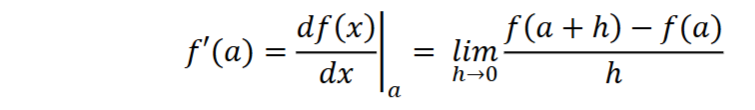

This is also called First-Order Derivative of 𝑓(𝑥) at 𝑎.

Numerically first-order derivative of 𝑓(𝑥) at 𝑎 can be approximated by
three main approximations, usually called as difference formulae:

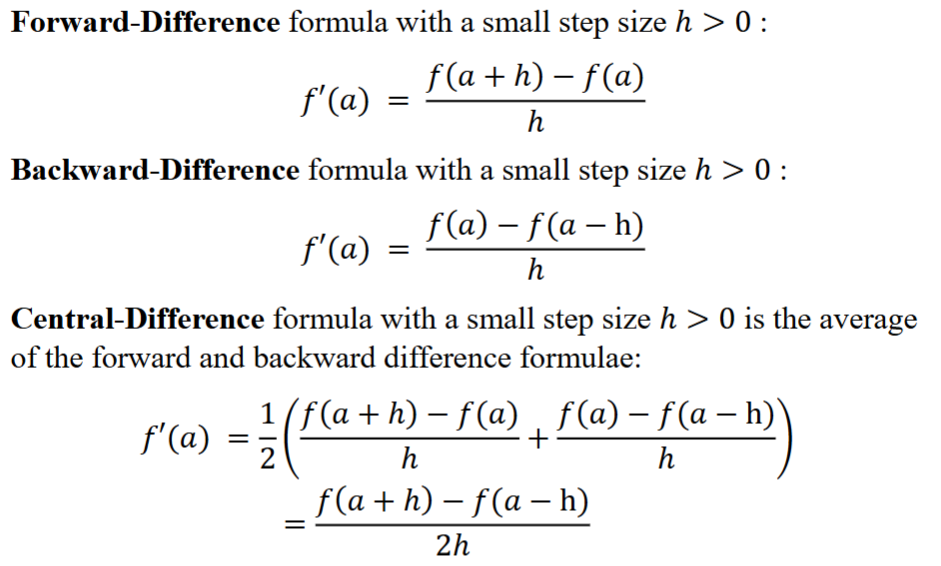

Note: The forward and backward difference formulae is valid only when
the function is twice continuously differentiable at point 𝑎 and around it,
i.e., 2nd order derivative exists at point 𝑎 and around it. Similarly, the
central-difference formula is valid only when the function is thrice
continuously differentiable at point 𝑎 and around it, i.e. 3rd order
derivative exists at point 𝑎 and around it.

**Error Analysis:**

Since these formulae are numerical approximations, we have some
errors between these formulae and the true value given by the analytical
definition. The smaller the value of step size ℎ, the smaller the error.
However, very small value of ℎ will result in large rounding error due to
limited precision of computer to represent floating point number.
Given that 0 < ℎ ≤ 1, the error between the true value and forward-
difference formula is of order ℎ, i.e., the error is approximately equal to
ℎ. Similarly, the error for backward-difference formula is of order ℎ.
However, the central-difference formula has error of order ℎ^2. So,
among the three formulae, the central-difference formula is a better
approximation.

**Part 2: Implement Numerical Differentiation:**

Let’s write a function called “derivative” which takes input parameters
𝑓, 𝑎, method and ℎ (with default method='central’ and ℎ = 0.01) and
returns the corresponding difference formula for 𝑓′(𝑎) with step size ℎ.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def derivative(func, a, method='forward', h=0.001):
'''Compute the difference formula for f'(a) with step size h.
Parameters
----------
fun : function
Vectorized function of one variable
a : number
Compute derivative at x = a
method : string
Difference formula: 'forward', 'backward' or 'central'
h : number
Step size in difference formula
Returns
-------
float
Difference formula:
forward: f(a+h) - f(a))/h
backward: f(a) - f(a-h))/h
'''
if method == 'forward':
return (func(a + h) - func(a))/h
elif method == 'backward':
return (func(a) - func(a - h))/h
else:
raise ValueError("Method must be 'central', 'forward' or
'backward'.")
if __name__ == "__main__":
# Let check our derivative function on simple functions.
# For example, we know d/dx (cos(x)) = - sin(x) at 0 should
# equal to zero.
actual_value = -np.sin(0.0)
result = derivative(np.cos, 0, method='forward')
print("Result = {:0.4f}".format(result))
print("Error = {:0.04f}".format(np.abs(result - actual_value)))

SyntaxError: unterminated string literal (detected at line 27) (4877539.py, line 27)

**Problem 1:** Consider varying the value of step size ℎ to a bigger value
and smaller value and check for the error. Consider varying the value of
𝑎 and again check the error.

In [2]:
import numpy as np
def derivative(func, a, method='forward', h=0.001):
    if method == 'forward':
        return (func(a + h) - func(a)) / h
    elif method == 'backward':
        return (func(a) - func(a - h)) / h
    else:
        raise ValueError("Method must be 'forward' or 'backward'")
h_values = [1, 0.1, 0.01, 0.001, 0.0001]
a_values = [0, 1, 2]
for a in a_values:
    actual_value = -np.sin(a)
    print(f"\nValue of a = {a}")
    print("Actual derivative =", actual_value)
    for h in h_values:
        result = derivative(np.cos, a, method='forward', h=h)
        error = abs(result - actual_value)
        print(f"h = {h}")
        print(f"Approximate derivative = {result}")
        print(f"Error = {error}")
        print()


Value of a = 0
Actual derivative = -0.0
h = 1
Approximate derivative = -0.45969769413186023
Error = 0.45969769413186023

h = 0.1
Approximate derivative = -0.049958347219741794
Error = 0.049958347219741794

h = 0.01
Approximate derivative = -0.004999958333473664
Error = 0.004999958333473664

h = 0.001
Approximate derivative = -0.0004999999583255033
Error = 0.0004999999583255033

h = 0.0001
Approximate derivative = -4.999999969612645e-05
Error = 4.999999969612645e-05


Value of a = 1
Actual derivative = -0.8414709848078965
h = 1
Approximate derivative = -0.9564491424152821
Error = 0.11497815760738561

h = 0.1
Approximate derivative = -0.8670618444256245
Error = 0.025590859617728

h = 0.01
Approximate derivative = -0.8441584493784293
Error = 0.002687464570532816

h = 0.001
Approximate derivative = -0.8417409956931188
Error = 0.00027001088522227157

h = 0.0001
Approximate derivative = -0.8414979985216231
Error = 2.7013713726598e-05


Value of a = 2
Actual derivative = -0.9092974268256817


**Problem 2:** In the above code, only the Forward and Backward
Difference formulae have been implemented. Please add the a few lines
of code to derivative() function to implement the Central Difference
formula and then compare its result with the Forward and Backward
Difference methods.

In [3]:
import numpy as np
def derivative(func, a, method='forward', h=0.001):
    if method == 'forward':
        return (func(a + h) - func(a)) / h
    elif method == 'backward':
        return (func(a) - func(a - h)) / h
    elif method == 'central':
        return (func(a + h) - func(a - h)) / (2 * h)
    else:
        raise ValueError("Method must be 'forward', 'backward', or 'central'")
a = 1
h = 0.001
actual_value = -np.sin(a)
forward_result = derivative(np.cos, a, method='forward', h=h)
backward_result = derivative(np.cos, a, method='backward', h=h)
central_result = derivative(np.cos, a, method='central', h=h)
forward_error = abs(forward_result - actual_value)
backward_error = abs(backward_result - actual_value)
central_error = abs(central_result - actual_value)
print("Actual derivative =", actual_value)
print()
print("Forward Difference")
print("Result =", forward_result)
print("Error =", forward_error)
print()
print("Backward Difference")
print("Result =", backward_result)
print("Error =", backward_error)
print()
print("Central Difference")
print("Result =", central_result)
print("Error =", central_error)

Actual derivative = -0.8414709848078965

Forward Difference
Result = -0.8417409956931188
Error = 0.00027001088522227157

Backward Difference
Result = -0.841200693432298
Error = 0.00027029137559853034

Central Difference
Result = -0.8414708445627084
Error = 1.4024518812938425e-07


**Problem 3:** The derivative() function can take an array of inputs for 𝑎
and return the derivatives for each 𝑎 value. So, calculate the derivative of 𝑦 = 𝑠in(𝑥) for multiple equidistant values and plot it along the true
values. You can use line:
x = np.linspace(0,5*np.pi,100)
to generate multiple equidistant values as the input array.

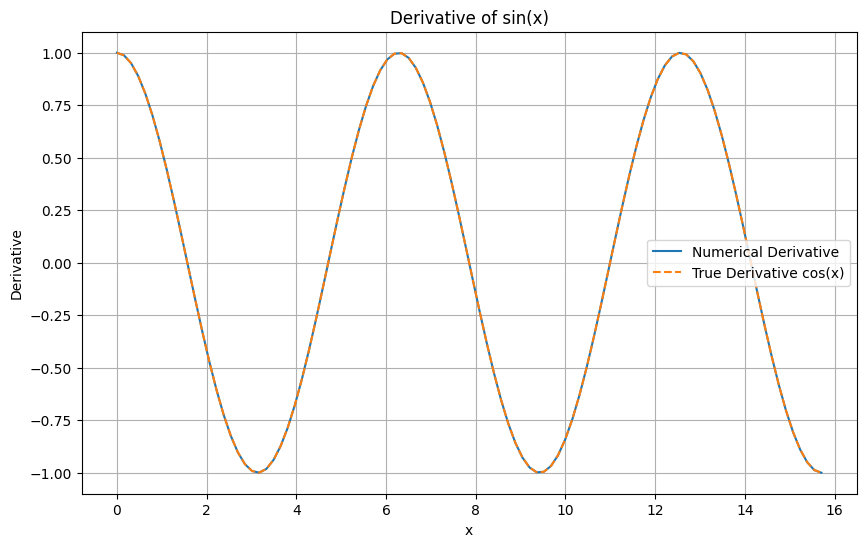

In [4]:
import numpy as np
import matplotlib.pyplot as plt
def derivative(func, a, method='central', h=0.001):
    if method == 'forward':
        return (func(a + h) - func(a)) / h
    elif method == 'backward':
        return (func(a) - func(a - h)) / h
    elif method == 'central':
        return (func(a + h) - func(a - h)) / (2 * h)
    else:
        raise ValueError("Method must be 'forward', 'backward', or 'central'")
x = np.linspace(0, 5 * np.pi, 100)
numerical_derivative = derivative(np.sin, x, method='central')
true_derivative = np.cos(x)
plt.figure(figsize=(10, 6))
plt.plot(x, numerical_derivative, label='Numerical Derivative')
plt.plot(x, true_derivative, '--', label='True Derivative cos(x)')
plt.xlabel('x')
plt.ylabel('Derivative')
plt.title('Derivative of sin(x)')
plt.legend()
plt.grid(True)
plt.show()

**Problem 4:** Try doing the same for other interesting functions you know.

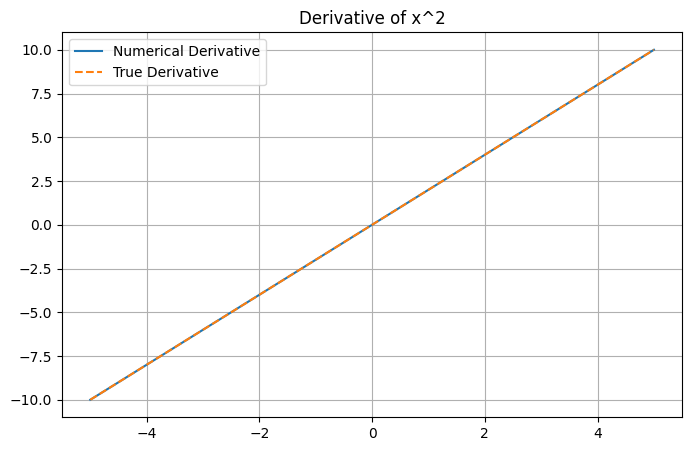

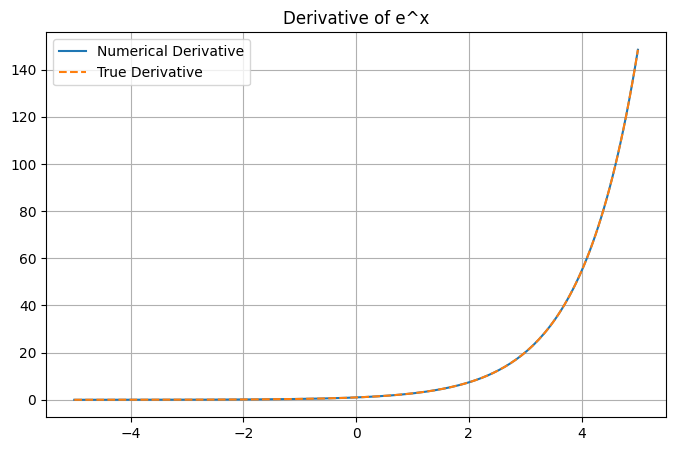

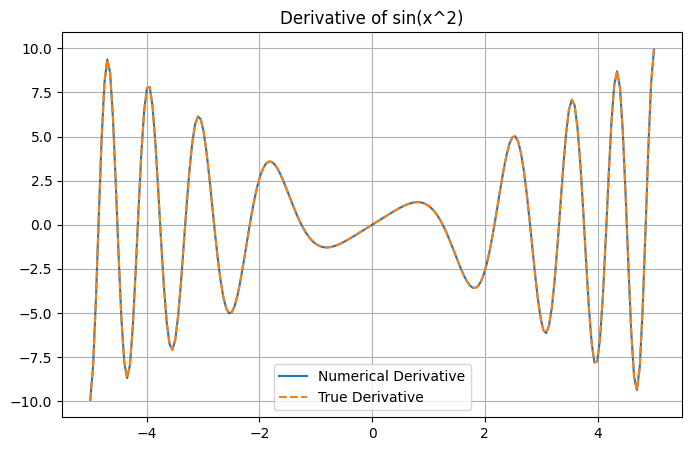

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def derivative(func, a, method='central', h=0.001):
    if method == 'forward':
        return (func(a + h) - func(a)) / h
    elif method == 'backward':
        return (func(a) - func(a - h)) / h
    elif method == 'central':
        return (func(a + h) - func(a - h)) / (2 * h)
    else:
        raise ValueError("Method must be 'forward', 'backward', or 'central'")
x = np.linspace(-5, 5, 200)
# -----------------------------
# 1. Function: x^2
# -----------------------------
y1_num = derivative(lambda x: x**2, x)
y1_true = 2 * x
plt.figure(figsize=(8,5))
plt.plot(x, y1_num, label='Numerical Derivative')
plt.plot(x, y1_true, '--', label='True Derivative')
plt.title('Derivative of x^2')
plt.legend()
plt.grid(True)
plt.show()
# -----------------------------
# 2. Function: e^x
# -----------------------------
y2_num = derivative(np.exp, x)
y2_true = np.exp(x)
plt.figure(figsize=(8,5))
plt.plot(x, y2_num, label='Numerical Derivative')
plt.plot(x, y2_true, '--', label='True Derivative')
plt.title('Derivative of e^x')
plt.legend()
plt.grid(True)
plt.show()
# -----------------------------
# 3. Function: sin(x^2)
# -----------------------------
y3_num = derivative(lambda x: np.sin(x**2), x)
y3_true = 2 * x * np.cos(x**2)
plt.figure(figsize=(8,5))
plt.plot(x, y3_num, label='Numerical Derivative')
plt.plot(x, y3_true, '--', label='True Derivative')
plt.title('Derivative of sin(x^2)')
plt.legend()
plt.grid(True)
plt.show()